# Business Glossary Manager

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-quality-governance/business-glossary/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-quality-governance/business-glossary/demo.ipynb)

One owned, versioned definition per business term - so "active user" stops meaning five different things to five teams. Each term carries an owner, definition, status, synonyms, related links, and the data assets it governs; the validator surfaces the governance gaps that let ambiguity creep back in.

**Contents**
1. [The term model](#model)
2. [A sample glossary with planted issues](#sample)
3. [Look up a term](#lookup)
4. [Validate - read the governance issues](#validate)
5. [Chart - issues by type](#chart)
6. [Summary](#summary)
7. [Try your own](#try)

_This notebook is self-contained - it re-defines the core logic so it runs anywhere with just pandas + matplotlib._

<a id="model"></a>
## Step 1 - the term model

A glossary is a dictionary of `Term` records keyed by a normalized name (so `Active User` and `active  user` are the same key). Each term names an **owner** (accountability), a **definition** (meaning), a **status** (`draft`/`approved`/`deprecated`), **synonyms**, **related** terms, and the **assets** (`table.column`) it governs.

`validate()` returns typed, explainable `Issue` records - each says which check fired and why - so findings are a prioritized review queue, not a black box.

In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from typing import Dict, List, Optional


@dataclass
class Term:
    name: str
    definition: str = ""
    owner: str = ""
    status: str = "draft"                       # draft | approved | deprecated
    synonyms: List[str] = field(default_factory=list)
    related: List[str] = field(default_factory=list)
    assets: List[str] = field(default_factory=list)


@dataclass
class Issue:
    issue_type: str      # ownerless | no-definition | orphan | synonym-collision
                         # | broken-related | deprecated-linked
    severity: str        # high | medium | low
    term: str
    message: str


def _norm(s: str) -> str:
    # Case/space-insensitive key so "Active User" == "active  user".
    return " ".join(s.strip().lower().split())


class Glossary:
    def __init__(self) -> None:
        self._terms: Dict[str, Term] = {}

    def add(self, term: Term) -> None:
        self._terms[_norm(term.name)] = term

    def get(self, name: str) -> Optional[Term]:
        # Exact lookup, or by any synonym.
        key = _norm(name)
        if key in self._terms:
            return self._terms[key]
        for t in self._terms.values():
            if key in (_norm(s) for s in t.synonyms):
                return t
        return None

    def all_terms(self) -> List[Term]:
        return sorted(self._terms.values(), key=lambda t: t.name.lower())

    def search(self, query: str) -> List[Term]:
        q = _norm(query)
        if not q:
            return self.all_terms()
        hits: List[Term] = []
        for t in self.all_terms():
            haystack = " ".join([t.name, " ".join(t.synonyms), t.definition])
            if q in _norm(haystack):
                hits.append(t)
        return hits

    def validate(self) -> List[Issue]:
        # Empty glossary -> no issues.
        issues: List[Issue] = []
        names = set(self._terms.keys())
        synonym_owners: Dict[str, List[str]] = {}

        for t in self.all_terms():
            if not t.owner.strip():
                issues.append(Issue("ownerless", "high", t.name,
                    "no owner - nobody is accountable for this definition"))
            if not t.definition.strip():
                issues.append(Issue("no-definition", "high", t.name,
                    "no definition - the term exists but says nothing"))
            if not t.assets and not t.related:
                issues.append(Issue("orphan", "low", t.name,
                    "orphaned - no linked assets and no related terms"))
            for r in t.related:
                if _norm(r) not in names:
                    issues.append(Issue("broken-related", "medium", t.name,
                        f"related term '{r}' does not exist in the glossary"))
            if t.status == "deprecated" and t.assets:
                issues.append(Issue("deprecated-linked", "high", t.name,
                    f"deprecated but still linked to {len(t.assets)} asset(s): "
                    f"{', '.join(t.assets)} - migrate consumers before retiring"))
            for syn in t.synonyms:
                synonym_owners.setdefault(_norm(syn), []).append(t.name)

        # Same synonym claimed by 2+ terms = one word meaning two things.
        for syn, owners in synonym_owners.items():
            if len(owners) > 1:
                for owner in owners:
                    issues.append(Issue("synonym-collision", "high", owner,
                        f"synonym '{syn}' is also claimed by: "
                        f"{', '.join(o for o in owners if o != owner)}"))

        order = {"high": 0, "medium": 1, "low": 2}
        return sorted(issues, key=lambda i: (order.get(i.severity, 3), i.issue_type))

    def to_markdown(self) -> str:
        if not self._terms:
            return "# Business Glossary\n\n_No terms defined yet._\n"
        lines = ["# Business Glossary", ""]
        for t in self.all_terms():
            lines.append(f"## {t.name}")
            lines.append(f"- **Status:** {t.status}")
            lines.append(f"- **Owner:** {t.owner or '_unassigned_'}")
            lines.append(f"- **Definition:** {t.definition or '_missing_'}")
            if t.synonyms:
                lines.append(f"- **Synonyms:** {', '.join(t.synonyms)}")
            if t.related:
                lines.append(f"- **Related:** {', '.join(t.related)}")
            if t.assets:
                lines.append(f"- **Linked assets:** {', '.join(t.assets)}")
            lines.append("")
        return "\n".join(lines)


print("Core model ready.")

Core model ready.


<a id="sample"></a>
## Step 2 - a sample glossary with planted issues

So you can see the validator earn its keep, we build a realistic SaaS glossary and deliberately plant governance gaps:

- **Signup** - ownerless AND no definition
- **Active User** and **Retention** both claim the synonym `MAU` - a collision
- **MRR** links to a related term `ARR` that was never defined - a broken ref
- **Bounce Rate** is `deprecated` but still linked to a live asset
- **Blended CAC** is an orphan - no assets, no related terms

In [2]:
def make_sample_glossary() -> Glossary:
    g = Glossary()
    g.add(Term(
        "Active User",
        "A user who logged in and took >=1 core action in the last 28 days.",
        owner="Growth Analytics", status="approved",
        synonyms=["Engaged User", "MAU"],
        related=["Churn", "Retention"],
        assets=["mart_users.is_active", "events.user_id"]))
    g.add(Term(
        "Churn",
        "A customer with zero core actions for 28 consecutive days.",
        owner="Retention Team", status="approved",
        synonyms=["Attrition"], related=["Active User", "MRR"],
        assets=["mart_users.churned_flag"]))
    g.add(Term(
        "MRR",
        "Monthly Recurring Revenue - normalized subscription revenue per month.",
        owner="Finance", status="approved",
        synonyms=["Monthly Recurring Revenue"],
        related=["ARR", "Churn"],            # ARR is a broken ref
        assets=["fct_revenue.mrr_usd"]))
    g.add(Term(
        "Retention",
        "Share of a cohort still active N periods after signup.",
        owner="Growth Analytics", status="approved",
        synonyms=["MAU"],                    # collides with Active User
        related=["Active User"],
        assets=["mart_cohorts.retained_pct"]))
    g.add(Term(
        "Signup", "",                        # no definition
        owner="",                            # ownerless
        status="draft", related=["Active User"],
        assets=["events.signup_ts"]))
    g.add(Term(
        "Bounce Rate",
        "Share of sessions with a single pageview and no interaction.",
        owner="Marketing", status="deprecated",
        assets=["fct_sessions.bounced"]))    # deprecated but still linked
    g.add(Term(
        "Blended CAC",
        "Total sales+marketing spend divided by all new customers in a period.",
        owner="Finance", status="draft"))    # orphan - no assets, no related
    return g


g = make_sample_glossary()
print(f"{len(g.all_terms())} terms loaded:")
for t in g.all_terms():
    print(f"  - {t.name:14s} [{t.status:10s}] owner={t.owner or '(none)'}")

7 terms loaded:
  - Active User    [approved  ] owner=Growth Analytics
  - Blended CAC    [draft     ] owner=Finance
  - Bounce Rate    [deprecated] owner=Marketing
  - Churn          [approved  ] owner=Retention Team
  - MRR            [approved  ] owner=Finance
  - Retention      [approved  ] owner=Growth Analytics
  - Signup         [draft     ] owner=(none)


<a id="lookup"></a>
## Step 3 - look up a term

`get()` resolves by exact name **or** by any synonym, so a business user searching `MAU` lands on the canonical `Active User` definition instead of guessing.

In [3]:
# Resolve a synonym straight to the canonical term.
hit = g.get("Engaged User")
print(f"Query 'Engaged User' -> canonical term: {hit.name}")
print(f"  Definition: {hit.definition}")
print(f"  Owner:      {hit.owner}")
print(f"  Assets:     {', '.join(hit.assets)}")

print("\nSubstring search for 'revenue':")
for t in g.search("revenue"):
    print(f"  - {t.name}: {t.definition}")

Query 'Engaged User' -> canonical term: Active User
  Definition: A user who logged in and took >=1 core action in the last 28 days.
  Owner:      Growth Analytics
  Assets:     mart_users.is_active, events.user_id

Substring search for 'revenue':
  - MRR: Monthly Recurring Revenue - normalized subscription revenue per month.


<a id="validate"></a>
## Step 4 - validate and read the governance issues

`validate()` returns one typed `Issue` per gap, most severe first. Every message explains WHY it fired, so a steward can act without reverse-engineering the check.

In [4]:
import pandas as pd

issues = g.validate()
issues_df = pd.DataFrame(
    [{"severity": i.severity, "issue_type": i.issue_type,
      "term": i.term, "message": i.message} for i in issues])
print(f"{len(issues)} governance issue(s) found\n")
issues_df

7 governance issue(s) found



,severity,issue_type,term,message
0,high,deprecated-linked,Bounce Rate,deprecated but still linked to 1 asset(s): fct...
1,high,no-definition,Signup,no definition - the term exists but says nothing
2,high,ownerless,Signup,no owner - nobody is accountable for this defi...
3,high,synonym-collision,Active User,synonym 'mau' is also claimed by: Retention
4,high,synonym-collision,Retention,synonym 'mau' is also claimed by: Active User
5,medium,broken-related,MRR,related term 'ARR' does not exist in the glossary
6,low,orphan,Blended CAC,orphaned - no linked assets and no related terms


<a id="chart"></a>
## Step 5 - issues by type

A quick visual so the eye lands on the most common class of gap first - and the PNG is saved for the README / a review deck.

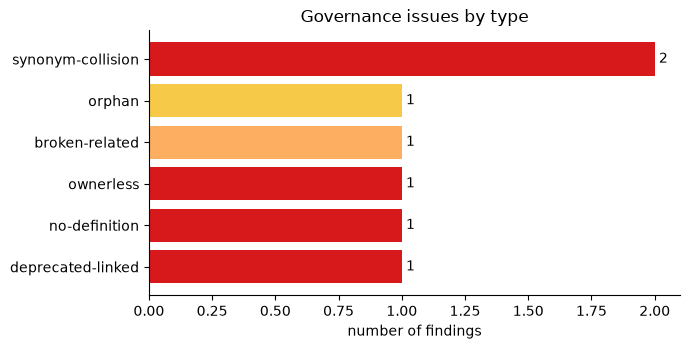

saved issues_by_type.png


In [5]:
import matplotlib.pyplot as plt

counts = issues_df["issue_type"].value_counts().sort_values()
colors = ["#d7191c" if t in ("ownerless", "no-definition", "synonym-collision",
          "deprecated-linked") else "#fdae61" if t == "broken-related"
          else "#f7c948" for t in counts.index]

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(counts.index, counts.values, color=colors)
ax.set_xlabel("number of findings")
ax.set_title("Governance issues by type")
ax.bar_label(ax.containers[0], padding=3)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("issues_by_type.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved issues_by_type.png")

<a id="summary"></a>
## Summary

The validator caught **every planted gap** with no hand-tuning:

| Term | Caught |
|------|--------|
| `Signup` | ownerless + no definition (two high findings) |
| `Active User` / `Retention` | synonym collision on `MAU` (high, both sides) |
| `MRR` | broken related ref to undefined `ARR` (medium) |
| `Bounce Rate` | deprecated but still linked to a live asset (high) |
| `Blended CAC` | orphan - no assets, no related terms (low) |

Each finding is typed and explainable, and the glossary exports to Markdown (`g.to_markdown()`) as a shareable reference doc. The point is not to automate meaning - it is to make the gaps visible so the owners can close them.

<a id="try"></a>
## Try your own

Build a glossary for your own terms and validate it - uncomment and edit:

In [6]:
# mine = Glossary()
# mine.add(Term(
#     "Qualified Lead",
#     "A lead meeting the MQL score threshold and matching an ICP firmographic.",
#     owner="Marketing Ops", status="approved",
#     synonyms=["MQL"], related=["Opportunity"],
#     assets=["mart_leads.is_qualified"]))
# for issue in mine.validate():
#     print(f"[{issue.severity}] {issue.issue_type} - {issue.term}: {issue.message}")
#
# print(mine.to_markdown())

---
Part of the [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) FDE portfolio - Day 94, Data Quality & Governance Suite.

For the interactive app: `streamlit run app.py` in this folder. Browse and search terms, open a term card, and read the governance-issues panel grouped by severity.